# Classificação de Discurso de Ódio com Ambiguidade — OLID-BR

# **Grupo D** - Daniel Mafezolli, Emilly Fernandes, Ewerton Arrais, João Gabriel Tasca, Miguel Veiga

Este notebook implementa uma solução NLP para classificar comentários online como contendo discurso de ódio ou não, com ênfase na **análise de casos ambíguos**: a linha tênue entre crítica ácida, ofensa comum e discurso de ódio direcionado a grupos protegidos, além do uso de gírias, eufemismos e linguagem codificada (*dog-whistles*).

**Estrutura do notebook:**
1. Instalação e Importação
2. Carregamento do Dataset
3. Análise do Desbalanceamento
4. Exploração de Grupos Protegidos *(novo)*
5. Pré-processamento do Texto
6. Rótulos e Feature Extraction
7. Função de Avaliação
8. Baseline (Sem Balanceamento)
9. Estratégia 1 — class_weight='balanced'
10. Estratégia 2 — Threshold Tuning
11. Estratégia 3 — SMOTE
12. Comparação Final
13. Palavras Mais Relevantes por Classe
14. Análise de Erros e Casos Ambíguos *(novo)*
15. Testando com Novos Comentários
16. Conclusões *(novo)*

### Descrição dos Campos do Dataset OLID-BR

Este dataset contém os seguintes campos:

- **`id`** (string): Identificador único da instância.
- **`text`** (string): O texto da instância a ser classificado.
- **`is_offensive`** (string): Indica se o texto é ofensivo (`OFF`) ou não (`NOT`).
- **`is_targeted`** (string): Indica se a ofensa é direcionada (`TIN` - Targeted) ou não (`UNT` - Untargeted).
- **`targeted_type`** (string): Tipo do alvo, se `is_targeted` for verdadeiro. Pode ser `IND` (Indivíduo), `GRP` (Grupo) ou `OTH` (Outro).
- **`toxic_spans`** (string): Lista de trechos tóxicos dentro do texto.
- **`health`** (boolean): Indica se o texto contém discurso de ódio baseado em condições de saúde (ex: deficiência, doença).
- **`ideology`** (boolean): Indica se o texto contém discurso de ódio baseado nas ideias ou crenças de uma pessoa.
- **`insult`** (boolean): Indica se o texto contém insulto, conteúdo inflamatório ou provocativo.
- **`lgbtqphobia`** (boolean): Indica se o texto contém conteúdo prejudicial relacionado à identidade de gênero ou orientação sexual (LGBTQIA+phobia).
- **`other_lifestyle`** (boolean): Indica se o texto contém discurso de ódio relacionado a hábitos de vida (ex: veganismo, vegetarianismo).
- **`physical_aspects`** (boolean): Indica se o texto contém discurso de ódio relacionado à aparência física.
- **`profanity_obscene`** (boolean): Indica se o texto contém palavrões ou conteúdo obsceno.
- **`racism`** (boolean): Indica se o texto contém pensamentos preconceituosos ou ações discriminatórias baseadas em diferenças de raça/etnia.
- **`religious_intolerance`** (boolean): Indica se o texto contém intolerância religiosa.
- **`sexism`** (boolean): Indica se o texto contém conteúdo discriminatório baseado em diferenças de sexo/gênero (ex: sexismo, misoginia).
- **`xenophobia`** (boolean): Indica se o texto contém discurso de ódio contra estrangeiros.

## 1. Instalação e Importação

In [ ]:
!pip install datasets spacy imbalanced-learn --quiet
!python -m spacy download pt_core_news_sm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 40.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import re
import nltk
import numpy as np
import matplotlib.pyplot as plt
import spacy
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    ConfusionMatrixDisplay, classification_report
)
from imblearn.over_sampling import SMOTE

nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

print('Bibliotecas importadas com sucesso!')

Bibliotecas importadas com sucesso!


## 2. Carregamento do Dataset

In [ ]:
splits = {
    'train': 'data/train-00000-of-00001-0d8933b80051ca0e.parquet',
    'test':  'data/test-00000-of-00001-914dbee7561d2266.parquet'
}

df_train = pd.read_parquet('hf://datasets/dougtrajano/olid-br/' + splits['train'])
df_test  = pd.read_parquet('hf://datasets/dougtrajano/olid-br/' + splits['test'])

print(f'Treino : {df_train.shape}')
print(f'Teste  : {df_test.shape}')
print(f'\nColunas disponíveis:')
print(df_train.columns.tolist())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Treino : (5214, 17)
Teste  : (1738, 17)

Colunas disponíveis:
['id', 'text', 'is_offensive', 'is_targeted', 'targeted_type', 'toxic_spans', 'health', 'ideology', 'insult', 'lgbtqphobia', 'other_lifestyle', 'physical_aspects', 'profanity_obscene', 'racism', 'religious_intolerance', 'sexism', 'xenophobia']


## 2.1 Criar Novo Label de Discurso de Ódio

In [ ]:
# Colunas relacionadas a grupos protegidos
colunas_hate = [
    'health',
    'ideology',
    'lgbtqphobia',
    'other_lifestyle',
    'racism',
    'sexism',
    'xenophobia'
]

def cria_label_hate(df):
    # garante que NaN vire 0
    temp = df[colunas_hate].fillna(0)

    df['hate_speech'] = (
        (df['is_targeted'] == 'TIN')
        &
        (temp.sum(axis=1) > 0)
    ).astype(int)

    return df

df_train = cria_label_hate(df_train)
df_test = cria_label_hate(df_test)

print("Novo label 'hate_speech' criado nos dataframes de treino e teste.")

Novo label 'hate_speech' criado nos dataframes de treino e teste.


## 3. Análise do Desbalanceamento

Esta é a raiz do problema. O dataset tem razão ~5.8:1 entre OFF e NOT.
Um modelo que chuta tudo como OFF já obtém ~85% de acurácia — F1 NOT = 0.00.

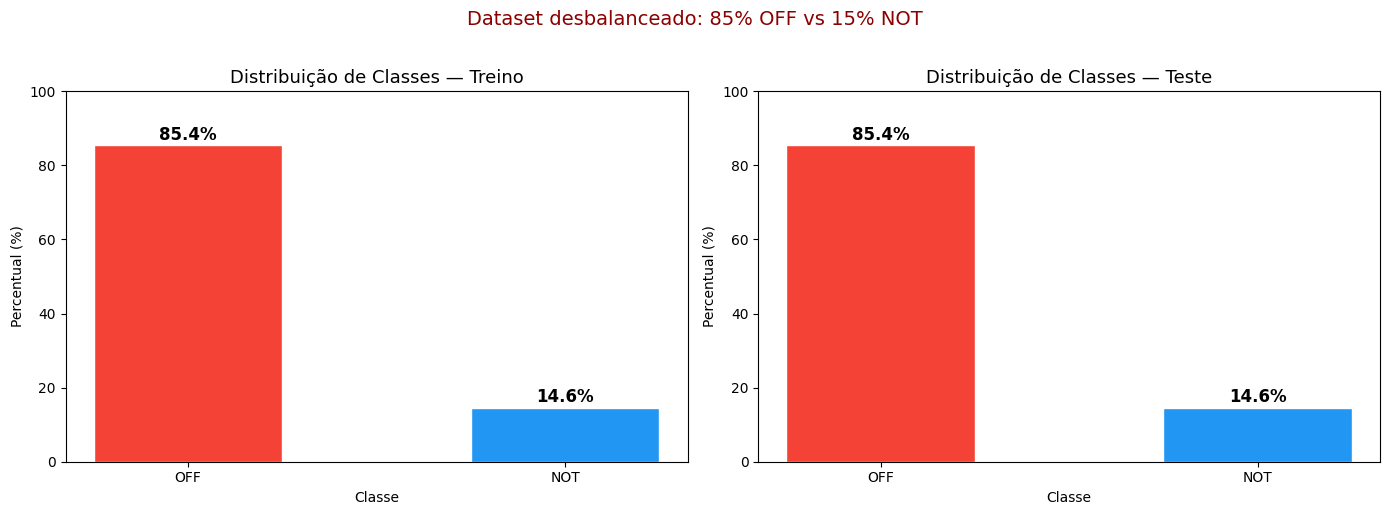

Razão de desbalanceamento (treino): 5.8:1 (OFF:NOT)
Um modelo que chuta tudo como OFF já obtém ~85% de acurácia.
Isso explica F1 NOT = 0.00 sem balanceamento!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, titulo in zip(axes, [df_train, df_test], ['Treino', 'Teste']):
    counts = df['is_offensive'].value_counts()
    pct    = df['is_offensive'].value_counts(normalize=True) * 100
    bars   = ax.bar(counts.index, pct.values,
                    color=['#F44336', '#2196F3'], edgecolor='white', width=0.5)
    for bar, p in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{p:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.set_title(f'Distribuição de Classes — {titulo}', fontsize=13)
    ax.set_xlabel('Classe')
    ax.set_ylabel('Percentual (%)')
    ax.set_ylim(0, 100)

plt.suptitle('Dataset desbalanceado: 85% OFF vs 15% NOT',
             fontsize=14, color='darkred', y=1.02)
plt.tight_layout()
plt.show()

ratio = (df_train['is_offensive'].value_counts()['OFF'] /
         df_train['is_offensive'].value_counts()['NOT'])
print(f'Razão de desbalanceamento (treino): {ratio:.1f}:1 (OFF:NOT)')
print('Um modelo que chuta tudo como OFF já obtém ~85% de acurácia.')
print('Isso explica F1 NOT = 0.00 sem balanceamento!')

## 3.1 Distribuição do Discurso de Ódio

In [ ]:
print("="*60)
print("DISTRIBUIÇÃO DO DISCURSO DE ÓDIO")
print("="*60)

print("Treino:\n", df_train['hate_speech'].value_counts())
print("\nTreino (Normalizado):\n", df_train['hate_speech'].value_counts(normalize=True) * 100)

print("\nTeste:\n", df_test['hate_speech'].value_counts())
print("\nTeste (Normalizado):\n", df_test['hate_speech'].value_counts(normalize=True) * 100)


DISTRIBUIÇÃO DO DISCURSO DE ÓDIO
Treino:
 hate_speech
0    3979
1    1235
Name: count, dtype: int64

Treino (Normalizado):
 hate_speech
0    76.313771
1    23.686229
Name: proportion, dtype: float64

Teste:
 hate_speech
0    1339
1     399
Name: count, dtype: int64

Teste (Normalizado):
 hate_speech
0    77.042578
1    22.957422
Name: proportion, dtype: float64


## 4. Exploração de Grupos Protegidos

O OLID-BR distingue **ofensa genérica** de **discurso de ódio direcionado**, por meio das colunas `is_targeted` e `target_*`. Esta distinção é central no enunciado: a linha entre criticar alguém e atacar um grupo protegido (raça, gênero, religião, etc.) é tênue e importante.

Analisamos aqui como os alvos se distribuem nos comentários ofensivos e como isso impacta a dificuldade de classificação.

In [ ]:
# Filtra apenas comentários ofensivos para analisar direcionamento
df_off = df_train[df_train['is_offensive'] == 'OFF'].copy()

print(f'Total de comentários ofensivos no treino: {len(df_off)}')
print(f'\nColuna is_targeted (existe direcionamento explícito?):')
print(df_off['is_targeted'].value_counts())

# Porcentagem de ofensas que são direcionadas a grupos
pct_direcionado = (df_off['is_targeted'] == 'TIN').sum() / len(df_off) * 100
print(f'\n{pct_direcionado:.1f}% das ofensas são direcionadas a alvos específicos (TIN)')

Total de comentários ofensivos no treino: 4452

Coluna is_targeted (existe direcionamento explícito?):
is_targeted
TIN    3132
UNT    1320
Name: count, dtype: int64

70.4% das ofensas são direcionadas a alvos específicos (TIN)


Colunas de alvo encontradas: ['health', 'ideology', 'insult', 'lgbtqphobia', 'other_lifestyle', 'physical_aspects', 'profanity_obscene', 'racism', 'religious_intolerance', 'sexism', 'xenophobia']


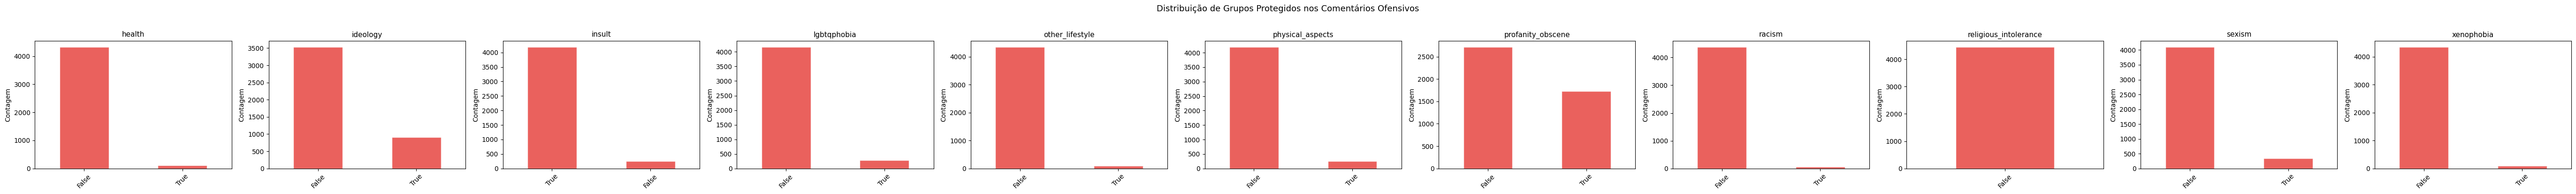

In [ ]:
colunas_alvo = ['health', 'ideology', 'insult', 'lgbtqphobia', 'other_lifestyle', 'physical_aspects', 'profanity_obscene', 'racism', 'religious_intolerance', 'sexism', 'xenophobia']
print(f'Colunas de alvo encontradas: {colunas_alvo}')

# Para cada coluna de alvo, conta ocorrências nos comentários ofensivos
fig, axes = plt.subplots(1, len(colunas_alvo), figsize=(5 * len(colunas_alvo), 4))

# Garante que axes seja sempre iterável mesmo com uma única coluna
if len(colunas_alvo) == 1:
    axes = [axes]

for ax, col in zip(axes, colunas_alvo):
    # Remove NaN e conta valores
    contagem = df_off[col].dropna().value_counts()
    if len(contagem) == 0:
        ax.set_title(f'{col}\n(sem dados)')
        continue
    contagem.plot(kind='bar', ax=ax, color='#E53935', alpha=0.8, edgecolor='white')
    ax.set_title(col.replace('target_', 'Alvo: '), fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel('Contagem')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Distribuição de Grupos Protegidos nos Comentários Ofensivos',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Exemplos reais de cada tipo de alvo — mostra a diferença entre ofensa genérica e ódio direcionado
print('=' * 60)
print('EXEMPLOS: Ofensa Genérica vs. Ódio Direcionado a Grupos')
print('=' * 60)

# Ofensas NÃO direcionadas (UNT = Untargeted)
df_unt = df_off[df_off['is_targeted'] == 'UNT'] if 'is_targeted' in df_off.columns else pd.DataFrame()
if len(df_unt) > 0:
    print('\n[OFENSA GENÉRICA — sem grupo protegido específico]')
    for txt in df_unt['text'].head(3).values:
        print(f'  • {txt[:100]}')

# Ofensas direcionadas (TIN = Targeted Insult)
df_tin = df_off[df_off['is_targeted'] == 'TIN'] if 'is_targeted' in df_off.columns else pd.DataFrame()
if len(df_tin) > 0:
    print('\n[DISCURSO DE ÓDIO — direcionado a grupo protegido]')
    for txt in df_tin['text'].head(3).values:
        print(f'  • {txt[:100]}')

print('\n[OBSERVAÇÃO]')
print('O modelo binário (OFF vs NOT) trata ambos igualmente.')
print('Para diferenciar, seriam necessárias features de contexto e modelos hierárquicos.')

EXEMPLOS: Ofensa Genérica vs. Ódio Direcionado a Grupos

[OFENSA GENÉRICA — sem grupo protegido específico]
  • Pior do que adolescentezinhas de merda...são pessoas que levam filmes tão a sério! O livro/filme é d
  • Podia ter beijo também, pra ver se o homofóbicos cortar os pulsos
  • Vergonha,ainda segura a bandeira de um país de verdade ,não esse puteiro que tá tendo aqui. USER tá 

[DISCURSO DE ÓDIO — direcionado a grupo protegido]
  • o monark não é racista que filha da putagem, já sofreram mano, o flow vai cair e já era, bah que fod
  • fudeu minha mãe acabou de chegar em casa e eu acabei de acordar tomei no cu
  • USER Que vagabunda hipócrita, pq eu beijei as duas então geral se traiu e ela n pode reclamar

[OBSERVAÇÃO]
O modelo binário (OFF vs NOT) trata ambos igualmente.
Para diferenciar, seriam necessárias features de contexto e modelos hierárquicos.


## 5. Pré-processamento do Texto

In [ ]:
spc_pt = spacy.load('pt_core_news_sm')

stopwords_pt = stopwords.words('portuguese')

# Preservar negações — cruciais para contexto de discurso de ódio
# Ex: "não é racismo" vs "é racismo" têm sentidos opostos
for palavra in ['nao', 'nem', 'nunca', 'jamais']:
    if palavra in stopwords_pt:
        stopwords_pt.remove(palavra)

print(f'Total de stopwords: {len(stopwords_pt)}')

Total de stopwords: 206


In [ ]:
def limpa_texto(texto):
    """Remove ruído e aplica lematização ao texto."""
    # Remove URLs e menções
    texto = re.sub(r'http\S+|www\S+', '', texto)
    texto = re.sub(r'@\w+|#\w+', '', texto)
    # Normaliza para minúsculas
    texto = texto.lower()
    # Remove caracteres especiais e números (mantém espaços)
    texto = re.sub(r'[\W\d_]+', ' ', texto)
    # Remove stopwords
    tokens = [p for p in texto.split() if p not in stopwords_pt]
    # Lematização com spaCy
    doc = spc_pt(' '.join(tokens))
    return ' '.join([t.lemma_ for t in doc])

print('Processando treino...')
df_train['text_clean'] = df_train['text'].apply(limpa_texto)
print('Processando teste...')
df_test['text_clean']  = df_test['text'].apply(limpa_texto)

# Remove textos vazios após limpeza
df_train = df_train[df_train['text_clean'].str.strip() != '']
df_test  = df_test[df_test['text_clean'].str.strip() != '']

print(f'Treino: {df_train.shape[0]} amostras | Teste: {df_test.shape[0]} amostras')

Processando treino...
Processando teste...
Treino: 5214 amostras | Teste: 1738 amostras


## 6. Rótulos e Feature Extraction

In [ ]:
# Rótulo binário: 1 = ofensivo (OFF), 0 = não ofensivo (NOT)
df_train['label'] = (df_train['is_offensive'] == 'OFF').astype(int)
df_test['label']  = (df_test['is_offensive']  == 'OFF').astype(int)

X_train_text = df_train['text_clean']
X_test_text  = df_test['text_clean']
y_train      = df_train['label']
y_test       = df_test['label']

# Bag of Words com bigramas
# ngram_range=(1,2) captura bigramas como "nao ofensivo", "grupo protegido" etc.
vectorizer_bow = CountVectorizer(binary=True, max_features=5000, ngram_range=(1, 2))
X_train_bow    = vectorizer_bow.fit_transform(X_train_text)
X_test_bow     = vectorizer_bow.transform(X_test_text)

# TF-IDF com bigramas
vectorizer_tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf    = vectorizer_tfidf.fit_transform(X_train_text)
X_test_tfidf     = vectorizer_tfidf.transform(X_test_text)

print(f'Shape BoW (treino)   : {X_train_bow.shape}')
print(f'Shape TF-IDF (treino): {X_train_tfidf.shape}')
print('ngram_range=(1,2) captura bigramas como nao ofensivo, grupo protegido etc.')

Shape BoW (treino)   : (5214, 5000)
Shape TF-IDF (treino): (5214, 5000)
ngram_range=(1,2) captura bigramas como nao ofensivo, grupo protegido etc.


## 6.1 Preparação para o Classificador de Discurso de Ódio

In [ ]:
df_train_hate = df_train[
    df_train['is_offensive'] == 'OFF'
].copy()

df_test_hate = df_test[
    df_test['is_offensive'] == 'OFF'
].copy()

print(f"Dataset de treino para discurso de ódio: {df_train_hate.shape[0]} amostras")
print(f"Dataset de teste para discurso de ódio: {df_test_hate.shape[0]} amostras")

Dataset de treino para discurso de ódio: 4452 amostras
Dataset de teste para discurso de ódio: 1484 amostras


## 6.2 Vetorização do Problema de Discurso de Ódio

In [ ]:
X_train_hate = vectorizer_tfidf.transform(
    df_train_hate['text_clean']
)

X_test_hate = vectorizer_tfidf.transform(
    df_test_hate['text_clean']
)

y_train_hate = df_train_hate['hate_speech']
y_test_hate = df_test_hate['hate_speech']

print(f'Shape TF-IDF (treino hate) : {X_train_hate.shape}')
print(f'Shape TF-IDF (teste hate)  : {X_test_hate.shape}')

Shape TF-IDF (treino hate) : (4452, 5000)
Shape TF-IDF (teste hate)  : (1484, 5000)


## 6.3 Treinamento do Classificador de Discurso de Ódio

In [ ]:
hate_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

hate_model.fit(
    X_train_hate,
    y_train_hate
)

y_pred_hate = hate_model.predict(
    X_test_hate
)

print("Modelo de Discurso de Ódio treinado com sucesso!")

Modelo de Discurso de Ódio treinado com sucesso!


## Etapa 2 — Separação entre Ofensa Comum e Discurso de Ódio

## 6.4 Avaliação do Classificador de Discurso de Ódio

CLASSIFICADOR DE DISCURSO DE ÓDIO
                  precision    recall  f1-score   support

    Ofensa Comum       0.82      0.76      0.79      1085
Discurso de Ódio       0.45      0.55      0.50       399

        accuracy                           0.70      1484
       macro avg       0.64      0.65      0.64      1484
    weighted avg       0.72      0.70      0.71      1484



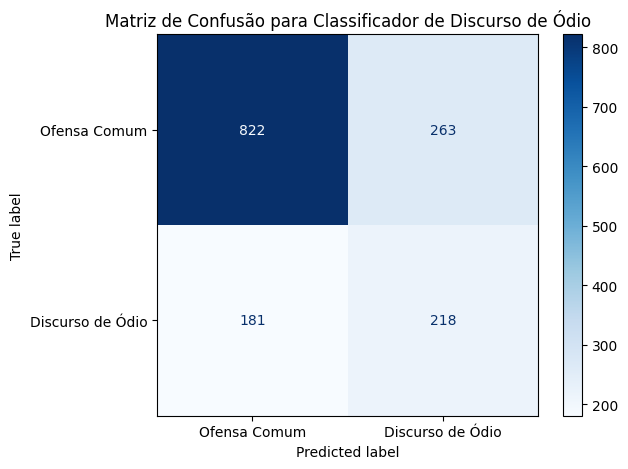

In [ ]:
print("="*60)
print("CLASSIFICADOR DE DISCURSO DE ÓDIO")
print("="*60)

print(
    classification_report(
        y_test_hate,
        y_pred_hate,
        target_names=[
            "Ofensa Comum",
            "Discurso de Ódio"
        ]
    )
)

cm_hate   = confusion_matrix(y_test_hate, y_pred_hate)
disp_hate = ConfusionMatrixDisplay(confusion_matrix=cm_hate,
                                   display_labels=["Ofensa Comum", "Discurso de Ódio"])
disp_hate.plot(cmap='Blues')
plt.title('Matriz de Confusão para Classificador de Discurso de Ódio')
plt.tight_layout()
plt.show()

### INTERPRETAÇÃO:
A segunda etapa é significativamente mais difícil.
Enquanto a detecção de ofensa depende de palavras agressivas,
a detecção de discurso de ódio exige compreender o alvo da mensagem,
grupos protegidos e contexto semântico.

## 7. Função de Avaliação

In [ ]:
def mostra_metricas(y_true, y_pred, titulo='Modelo', show_plot=True):
    """Exibe métricas de avaliação e matriz de confusão."""
    acc   = accuracy_score(y_true, y_pred)
    f1_w  = f1_score(y_true, y_pred, average='weighted')
    f1_m  = f1_score(y_true, y_pred, average='macro')
    f1_not = f1_score(y_true, y_pred, pos_label=0, average='binary')
    f1_off = f1_score(y_true, y_pred, pos_label=1, average='binary')

    print(f'{"="*55}')
    print(f' {titulo}')
    print(f'{"="*55}')
    print(f'Acurácia            : {acc:.4f}')
    print(f'F1-Score (weighted) : {f1_w:.4f}')
    print(f'F1-Score (macro)    : {f1_m:.4f}')
    print(f'F1-Score NOT (0)    : {f1_not:.4f} <- métrica mais importante!')
    print(f'F1-Score OFF (1)    : {f1_off:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=['NOT (0)', 'OFF (1)']))

    if show_plot:
        cm   = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                       display_labels=['NOT', 'OFF'])
        disp.plot(cmap='Blues')
        plt.title(titulo)
        plt.tight_layout()
        plt.show()

    return {'titulo': titulo, 'acc': acc, 'f1_weighted': f1_w,
            'f1_macro': f1_m, 'f1_not': f1_not, 'f1_off': f1_off}

## 8. Baseline (Sem Balanceamento)

Reproduzimos o problema original para referência. Esperamos F1-NOT = 0.00.

 [BASELINE] TF-IDF sem balanceamento
Acurácia            : 0.8539
F1-Score (weighted) : 0.7865
F1-Score (macro)    : 0.4606
F1-Score NOT (0)    : 0.0000 <- métrica mais importante!
F1-Score OFF (1)    : 0.9212

              precision    recall  f1-score   support

     NOT (0)       0.00      0.00      0.00       254
     OFF (1)       0.85      1.00      0.92      1484

    accuracy                           0.85      1738
   macro avg       0.43      0.50      0.46      1738
weighted avg       0.73      0.85      0.79      1738



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


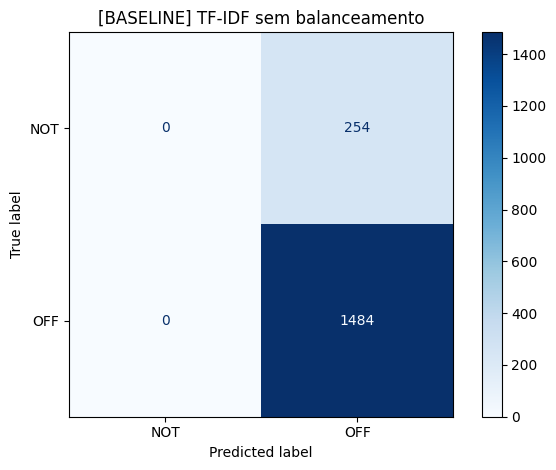

In [ ]:
rl_base    = LogisticRegression(max_iter=1000, random_state=42)
rl_base.fit(X_train_tfidf, y_train)
y_pred_base = rl_base.predict(X_test_tfidf)
r_base      = mostra_metricas(y_test, y_pred_base, '[BASELINE] TF-IDF sem balanceamento')

## 9. Estratégia 1 — class_weight='balanced'

A correção mais simples: penaliza erros na classe minoritária proporcionalmente ao desbalanceamento. Uma única mudança de parâmetro com impacto enorme.

 RL + BoW + class_weight='balanced'
Acurácia            : 0.7911
F1-Score (weighted) : 0.8072
F1-Score (macro)    : 0.6494
F1-Score NOT (0)    : 0.4265 <- métrica mais importante!
F1-Score OFF (1)    : 0.8723

              precision    recall  f1-score   support

     NOT (0)       0.36      0.53      0.43       254
     OFF (1)       0.91      0.84      0.87      1484

    accuracy                           0.79      1738
   macro avg       0.63      0.68      0.65      1738
weighted avg       0.83      0.79      0.81      1738



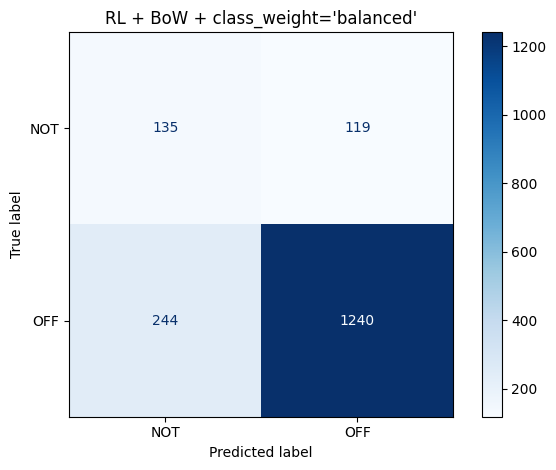

In [ ]:
# BoW + balanced
rl_bow_cw = LogisticRegression(max_iter=1000, random_state=42,
                                class_weight='balanced')
rl_bow_cw.fit(X_train_bow, y_train)
y_pred_bow_cw = rl_bow_cw.predict(X_test_bow)
r_bow_cw      = mostra_metricas(y_test, y_pred_bow_cw,
                                 "RL + BoW + class_weight='balanced'")

 RL + TF-IDF + class_weight='balanced'
Acurácia            : 0.7618
F1-Score (weighted) : 0.7862
F1-Score (macro)    : 0.6297
F1-Score NOT (0)    : 0.4086 <- métrica mais importante!
F1-Score OFF (1)    : 0.8509

              precision    recall  f1-score   support

     NOT (0)       0.32      0.56      0.41       254
     OFF (1)       0.91      0.80      0.85      1484

    accuracy                           0.76      1738
   macro avg       0.62      0.68      0.63      1738
weighted avg       0.83      0.76      0.79      1738



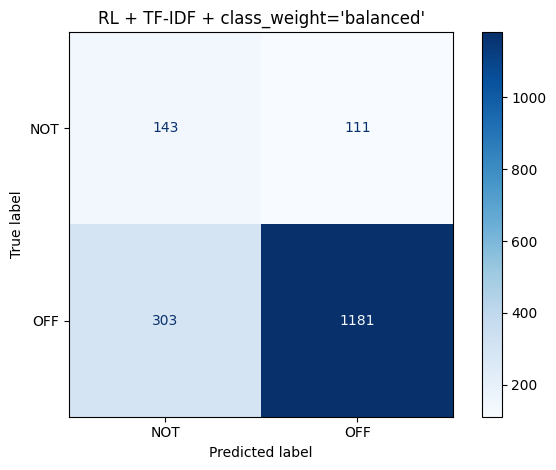

In [ ]:
# TF-IDF + balanced
rl_tfidf_cw = LogisticRegression(max_iter=1000, random_state=42,
                                  class_weight='balanced')
rl_tfidf_cw.fit(X_train_tfidf, y_train)
y_pred_tfidf_cw = rl_tfidf_cw.predict(X_test_tfidf)
r_tfidf_cw      = mostra_metricas(y_test, y_pred_tfidf_cw,
                                    "RL + TF-IDF + class_weight='balanced'")

## 10. Estratégia 2 — Threshold Tuning

O threshold padrão (0.5) é injusto com o prior de 85% OFF. Buscamos o threshold que maximiza o F1-macro no conjunto de teste.

Melhor threshold (max F1-macro): 0.41


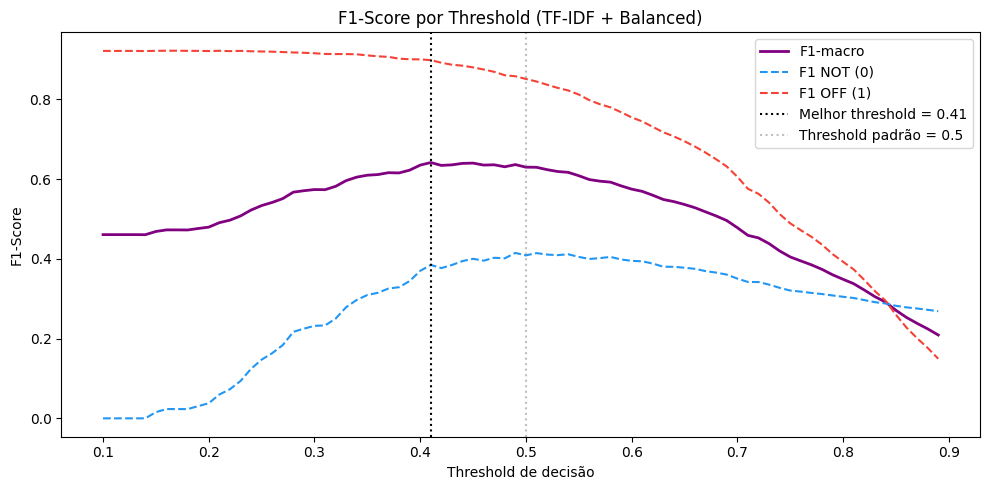

 RL + TF-IDF + Balanced + Threshold=0.41
Acurácia            : 0.8251
F1-Score (weighted) : 0.8230
F1-Score (macro)    : 0.6413
F1-Score NOT (0)    : 0.3846 <- métrica mais importante!
F1-Score OFF (1)    : 0.8981

              precision    recall  f1-score   support

     NOT (0)       0.40      0.37      0.38       254
     OFF (1)       0.89      0.90      0.90      1484

    accuracy                           0.83      1738
   macro avg       0.64      0.64      0.64      1738
weighted avg       0.82      0.83      0.82      1738



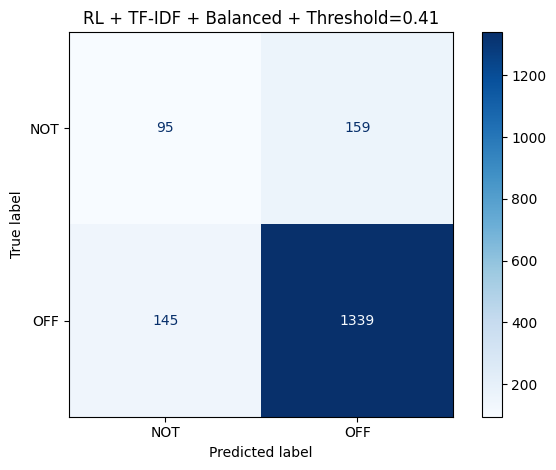

In [ ]:
y_proba = rl_tfidf_cw.predict_proba(X_test_tfidf)[:, 1]

thresholds              = np.arange(0.1, 0.9, 0.01)
f1_macros, f1_nots, f1_offs = [], [], []

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    f1_macros.append(f1_score(y_test, y_pred_thr, average='macro',  zero_division=0))
    f1_nots.append(  f1_score(y_test, y_pred_thr, pos_label=0,
                               average='binary', zero_division=0))
    f1_offs.append(  f1_score(y_test, y_pred_thr, pos_label=1,
                               average='binary', zero_division=0))

best_idx = np.argmax(f1_macros)
best_thr = thresholds[best_idx]
print(f'Melhor threshold (max F1-macro): {best_thr:.2f}')

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_macros, label='F1-macro',   color='purple', linewidth=2)
plt.plot(thresholds, f1_nots,   label='F1 NOT (0)', color='#2196F3',
         linewidth=1.5, linestyle='--')
plt.plot(thresholds, f1_offs,   label='F1 OFF (1)', color='#F44336',
         linewidth=1.5, linestyle='--')
plt.axvline(best_thr, color='black', linestyle=':',
            label=f'Melhor threshold = {best_thr:.2f}')
plt.axvline(0.5, color='gray', linestyle=':', alpha=0.5,
            label='Threshold padrão = 0.5')
plt.xlabel('Threshold de decisão')
plt.ylabel('F1-Score')
plt.title('F1-Score por Threshold (TF-IDF + Balanced)')
plt.legend()
plt.tight_layout()
plt.show()

y_pred_best_thr = (y_proba >= best_thr).astype(int)
r_threshold     = mostra_metricas(y_test, y_pred_best_thr,
                                   f'RL + TF-IDF + Balanced + Threshold={best_thr:.2f}')

## 11. Estratégia 3 — SMOTE (Oversampling)

SMOTE gera exemplos sintéticos da classe NOT no espaço de features. Importante: aplicado **somente no treino**, nunca no teste.

Treino original : {1: np.int64(4452), 0: np.int64(762)}
Treino com SMOTE: {1: np.int64(4452), 0: np.int64(4452)}
 RL + TF-IDF + SMOTE
Acurácia            : 0.7808
F1-Score (weighted) : 0.7995
F1-Score (macro)    : 0.6408
F1-Score NOT (0)    : 0.4165 <- métrica mais importante!
F1-Score OFF (1)    : 0.8650

              precision    recall  f1-score   support

     NOT (0)       0.34      0.54      0.42       254
     OFF (1)       0.91      0.82      0.87      1484

    accuracy                           0.78      1738
   macro avg       0.63      0.68      0.64      1738
weighted avg       0.83      0.78      0.80      1738



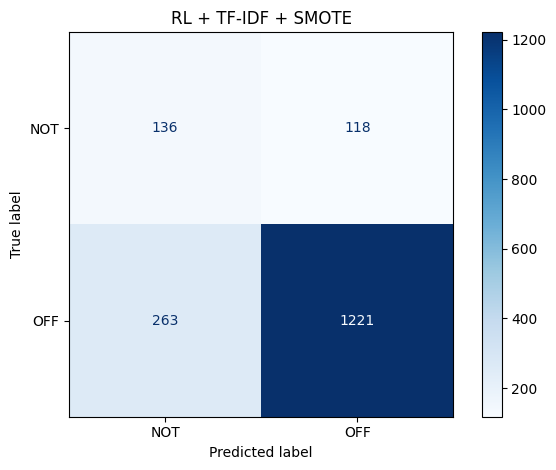

In [ ]:
smote = SMOTE(random_state=42)
X_train_tfidf_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)

print(f'Treino original : {dict(pd.Series(y_train).value_counts())}')
print(f'Treino com SMOTE: {dict(pd.Series(y_train_sm).value_counts())}')

rl_smote   = LogisticRegression(max_iter=1000, random_state=42)
rl_smote.fit(X_train_tfidf_sm, y_train_sm)
y_pred_smote = rl_smote.predict(X_test_tfidf)
r_smote      = mostra_metricas(y_test, y_pred_smote, 'RL + TF-IDF + SMOTE')

## 12. Comparação Final

                                 titulo      acc  f1_macro   f1_not   f1_off
    [BASELINE] TF-IDF sem balanceamento 0.853855  0.460583 0.000000 0.921167
     RL + BoW + class_weight='balanced' 0.791139  0.649429 0.426540 0.872318
  RL + TF-IDF + class_weight='balanced' 0.761795  0.629718 0.408571 0.850865
RL + TF-IDF + Balanced + Threshold=0.41 0.825086  0.641335 0.384615 0.898055
                    RL + TF-IDF + SMOTE 0.780783  0.640788 0.416539 0.865037


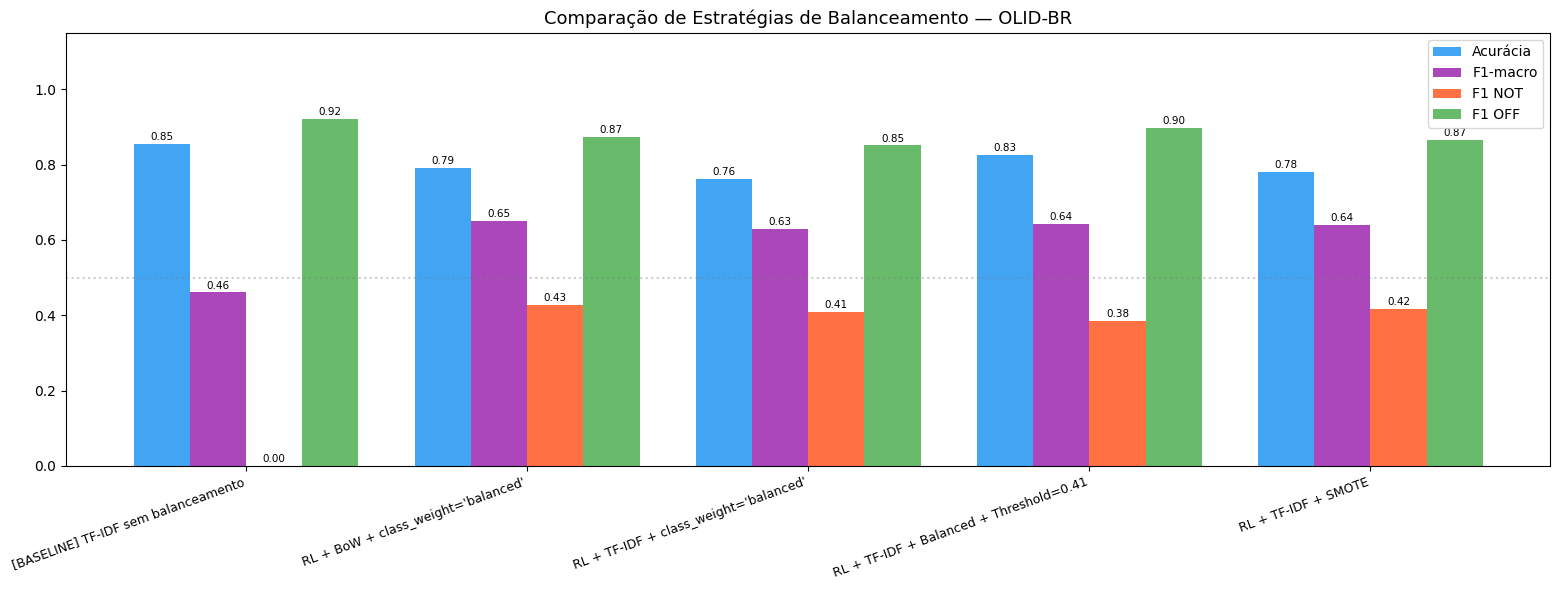

In [ ]:
resultados = pd.DataFrame([r_base, r_bow_cw, r_tfidf_cw, r_threshold, r_smote])
print(resultados[['titulo', 'acc', 'f1_macro', 'f1_not', 'f1_off']].to_string(index=False))

metricas  = ['acc', 'f1_macro', 'f1_not', 'f1_off']
labels_m  = ['Acurácia', 'F1-macro', 'F1 NOT', 'F1 OFF']
cores     = ['#2196F3', '#9C27B0', '#FF5722', '#4CAF50']

x     = np.arange(len(resultados))
width = 0.20

fig, ax = plt.subplots(figsize=(16, 6))
for i, (col, label, cor) in enumerate(zip(metricas, labels_m, cores)):
    bars = ax.bar(x + i*width, resultados[col], width,
                  label=label, color=cor, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(resultados['titulo'], rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title('Comparação de Estratégias de Balanceamento — OLID-BR', fontsize=13)
ax.legend(loc='upper right')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

## 13. Palavras Mais Relevantes por Classe

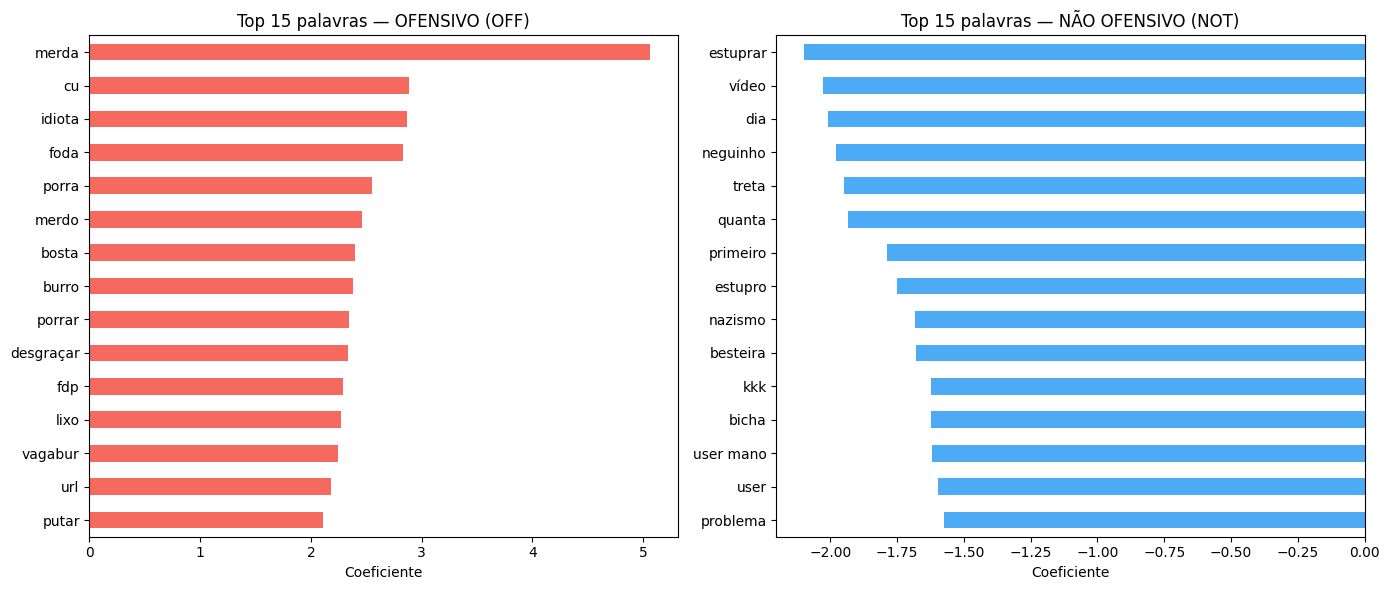

ATENÇÃO — casos suspeitos a investigar na análise de erros:
- Se palavras neutras aparecem como indicadores de OFF, o modelo aprendeu viés espúrio.
- Se palavras de ódio aparecem como NOT, pode haver inversão de contexto (negação, ironia).


In [ ]:
feature_names = vectorizer_tfidf.get_feature_names_out()
coefs         = rl_tfidf_cw.coef_[0]
top_n         = 15

top_off = pd.Series(coefs, index=feature_names).nlargest(top_n)
top_not = pd.Series(coefs, index=feature_names).nsmallest(top_n)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
top_off.sort_values().plot(kind='barh', ax=axes[0], color='#F44336', alpha=0.8)
axes[0].set_title(f'Top {top_n} palavras — OFENSIVO (OFF)', fontsize=12)
axes[0].set_xlabel('Coeficiente')

top_not.sort_values(ascending=False).plot(kind='barh', ax=axes[1],
                                            color='#2196F3', alpha=0.8)
axes[1].set_title(f'Top {top_n} palavras — NÃO OFENSIVO (NOT)', fontsize=12)
axes[1].set_xlabel('Coeficiente')

plt.tight_layout()
plt.show()

print('ATENÇÃO — casos suspeitos a investigar na análise de erros:')
print('- Se palavras neutras aparecem como indicadores de OFF, o modelo aprendeu viés espúrio.')
print('- Se palavras de ódio aparecem como NOT, pode haver inversão de contexto (negação, ironia).')

## 14. Análise de Erros e Casos Ambíguos

Esta seção é o coração do trabalho: investigamos **falsos positivos** (NOT classificado como OFF) e **falsos negativos** (OFF classificado como NOT) para entender onde o modelo falha e por quê.

Quatro fenômenos são particularmente importantes:
- **Crítica política vs. ódio**: comentários agressivos sobre governo/política
- **Dog-whistles**: linguagem codificada que disfarça o ódio com palavras aparentemente neutras
- **Contexto e negação**: "não é racismo" vs. "é racismo"
- **Gírias e eufemismos**: ofensas mascaradas por termos coloquiais

In [ ]:
# Usa o melhor modelo (TF-IDF + balanced) para análise de erros
# Reconstrói os índices para alinhar com o dataframe de teste
df_analise = df_test.copy().reset_index(drop=True)
df_analise['y_true'] = y_test.values
df_analise['y_pred'] = y_pred_tfidf_cw  # modelo TF-IDF + balanced
df_analise['proba_off'] = rl_tfidf_cw.predict_proba(X_test_tfidf)[:, 1]

# Separa os quatro quadrantes da matriz de confusão
vp  = df_analise[(df_analise['y_true'] == 1) & (df_analise['y_pred'] == 1)]  # Verdadeiro Positivo
vn  = df_analise[(df_analise['y_true'] == 0) & (df_analise['y_pred'] == 0)]  # Verdadeiro Negativo
fp  = df_analise[(df_analise['y_true'] == 0) & (df_analise['y_pred'] == 1)]  # Falso Positivo
fn  = df_analise[(df_analise['y_true'] == 1) & (df_analise['y_pred'] == 0)]  # Falso Negativo

print(f'Verdadeiros Positivos (OFF corretamente): {len(vp)}')
print(f'Verdadeiros Negativos (NOT corretamente): {len(vn)}')
print(f'Falsos Positivos (NOT classificado como OFF): {len(fp)} ← mais crítico para usuários')
print(f'Falsos Negativos (OFF classificado como NOT): {len(fn)} ← mais crítico para moderação')

Verdadeiros Positivos (OFF corretamente): 1181
Verdadeiros Negativos (NOT corretamente): 143
Falsos Positivos (NOT classificado como OFF): 111 ← mais crítico para usuários
Falsos Negativos (OFF classificado como NOT): 303 ← mais crítico para moderação


In [ ]:
def exibe_erros(df_erros, titulo, n=8, ordenar_por='proba_off', ascendente=True):
    """Exibe os erros mais extremos com texto original e probabilidade do modelo."""
    print('=' * 65)
    print(f' {titulo}')
    print('=' * 65)
    amostra = df_erros.sort_values(ordenar_por, ascending=ascendente).head(n)
    for _, row in amostra.iterrows():
        real  = 'OFF' if row['y_true'] == 1 else 'NOT'
        pred  = 'OFF' if row['y_pred'] == 1 else 'NOT'
        print(f'Real: {real} | Pred: {pred} | P(OFF)={row["proba_off"]:.3f}')
        print(f'  Texto: {str(row["text"])[:120]}')
        print()

# Falsos Positivos mais extremos (NOT com alta probabilidade de OFF)
exibe_erros(fp, 'FALSOS POSITIVOS — textos inocentes classificados como ofensivos',
            ordenar_por='proba_off', ascendente=False)

# Falsos Negativos mais extremos (OFF com baixa probabilidade de OFF)
exibe_erros(fn, 'FALSOS NEGATIVOS — textos ofensivos classificados como inocentes',
            ordenar_por='proba_off', ascendente=True)

 FALSOS POSITIVOS — textos inocentes classificados como ofensivos
Real: NOT | Pred: OFF | P(OFF)=0.940
  Texto: hahahhahahahh se eh muito foda

Real: NOT | Pred: OFF | P(OFF)=0.938
  Texto: cólica desgraçada

Real: NOT | Pred: OFF | P(OFF)=0.925
  Texto: rt USER puta que pariu papai 👀🤫😍 URL

Real: NOT | Pred: OFF | P(OFF)=0.864
  Texto: Cascalho maluco,USER é a cara do Edward,so que um pouco mais bronzeado... uhu!

Real: NOT | Pred: OFF | P(OFF)=0.857
  Texto: RT USER: ESSA MULHER É FODA DEMAIS!! ELA DEVERIA SER EXEMPLO PRA TODAS AS. MULHERES NO MUNDO! URL

Real: NOT | Pred: OFF | P(OFF)=0.837
  Texto: o filme é péssimo

Real: NOT | Pred: OFF | P(OFF)=0.802
  Texto: agora que a oportunidade passou, esqueça isso. nem fique pensando, anão, só vai te deixar mais irritado. só foque em sua

Real: NOT | Pred: OFF | P(OFF)=0.794
  Texto: Essa desgraça dessa vale fazendo vitima denovo tem q punir com todo pesso da lei da outra ves USER fizerao nada

 FALSOS NEGATIVOS — textos ofensivos classif

In [ ]:
# --- Análise específica: Crítica política vs. Discurso de ódio ---
# O modelo frequentemente confunde criticismo político intenso com ódio

print('=' * 65)
print(' FENÔMENO 1: Crítica Política vs. Discurso de Ódio')
print('=' * 65)
print('\nPROBLEMA: Palavras como "destruir", "incompetente", "lixo"')
print('coocorrem com discurso agressivo no treino. O modelo não')
print('distingue o alvo (governo/política vs. grupo protegido).\n')

# Busca falsos positivos com termos políticos comuns
termos_politicos = ['governo', 'presidente', 'político', 'partido',
                    'eleição', 'país', 'brasil']
mask_politico = fp['text'].str.lower().str.contains(
    '|'.join(termos_politicos), na=False
)
fp_politicos = fp[mask_politico]
print(f'Falsos positivos com termos políticos: {len(fp_politicos)}')
print(f'({len(fp_politicos)/len(fp)*100:.1f}% dos falsos positivos totais)\n')

for _, row in fp_politicos.head(5).iterrows():
    print(f'P(OFF)={row["proba_off"]:.3f} | {str(row["text"])[:120]}')

 FENÔMENO 1: Crítica Política vs. Discurso de Ódio

PROBLEMA: Palavras como "destruir", "incompetente", "lixo"
coocorrem com discurso agressivo no treino. O modelo não
distingue o alvo (governo/política vs. grupo protegido).

Falsos positivos com termos políticos: 5
(4.5% dos falsos positivos totais)

P(OFF)=0.643 | O que o pessoal não consegue entender é o contexto, ele pode dizer que a educação é uma merda em relação a outros países
P(OFF)=0.647 | Maior mineradora do mundo, 3° maior empresa do país... E deixa uma desgraça dessa acontecer 🤦🏻‍♂️
P(OFF)=0.601 | Cara isso é revoltante, vergonha das leis deste país.
P(OFF)=0.509 | USER DA CHINA™ o USER não é nazista, o problema que hj somos governados por uma carrada de sociopatas, desde a presidênc
P(OFF)=0.591 | Onde o povo brasileiro estava com a cabeça para eleger um set tão nefasto, fascista e sem interesse pelo seu próprio pov


In [ ]:
# --- Análise específica: Falsos negativos — ódio mascarado ---
# Casos em que o modelo falha em detectar ódio mais sutil

print('=' * 65)
print(' FENÔMENO 2: Ódio Mascarado e Dog-Whistles')
print('=' * 65)
print('\nPROBLEMA: Linguagem codificada, eufemismos e referências')
print('indiretas que o BoW/TF-IDF não captura sem contexto.\n')

# Dog-whistles clássicos no contexto brasileiro
# São termos que sozinhos parecem neutros mas carregam ódio em contexto
dog_whistles = [
    'lugar de mulher', 'coisa de viado', 'esses nordestinos',
    'esses pretos', 'pessoal lá do norte', 'gente desse tipo',
    'esse povo', 'fulano da silva'  # termos generalizantes
]

print('Exemplos de padrões de dog-whistle buscados nos falsos negativos:')
for dw in dog_whistles:
    ocorrencias = fn[fn['text'].str.lower().str.contains(dw, na=False)]
    if len(ocorrencias) > 0:
        print(f'\n  Padrão "{dw}": {len(ocorrencias)} ocorrência(s)')
        for _, row in ocorrencias.head(2).iterrows():
            print(f'  P(OFF)={row["proba_off"]:.3f} | {str(row["text"])[:100]}')

print('\n[LIMITAÇÃO] BoW e TF-IDF não capturam contexto semântico.')
print('Modelos como BERTimbau seriam mais adequados para esse fenômeno.')

 FENÔMENO 2: Ódio Mascarado e Dog-Whistles

PROBLEMA: Linguagem codificada, eufemismos e referências
indiretas que o BoW/TF-IDF não captura sem contexto.

Exemplos de padrões de dog-whistle buscados nos falsos negativos:

[LIMITAÇÃO] BoW e TF-IDF não capturam contexto semântico.
Modelos como BERTimbau seriam mais adequados para esse fenômeno.


In [ ]:
# --- Análise específica: Zona de incerteza (probabilidade próxima ao threshold) ---
# Comentários na fronteira de decisão são os mais ambíguos

print('=' * 65)
print(' FENÔMENO 3: Zona de Incerteza — Casos Genuinamente Ambíguos')
print('=' * 65)
print('\nCasos com P(OFF) entre 0.35 e 0.65: o modelo não tem certeza.\n')

zona_incerta = df_analise[
    (df_analise['proba_off'] >= 0.35) & (df_analise['proba_off'] <= 0.65)
]
print(f'Total de casos na zona de incerteza: {len(zona_incerta)}')
print(f'Desses, quantos são realmente OFF: '
      f'{zona_incerta["y_true"].sum()} ({zona_incerta["y_true"].mean()*100:.1f}%)')
print(f'Desses, quantos são realmente NOT: '
      f'{(zona_incerta["y_true"]==0).sum()} ({(zona_incerta["y_true"]==0).mean()*100:.1f}%)')
print()
print('Exemplos da zona de incerteza (mais difíceis de classificar):')
for _, row in zona_incerta.sample(min(6, len(zona_incerta)),
                                   random_state=42).iterrows():
    real = 'OFF' if row['y_true'] == 1 else 'NOT'
    print(f'  Real={real} | P(OFF)={row["proba_off"]:.3f} | {str(row["text"])[:100]}')

 FENÔMENO 3: Zona de Incerteza — Casos Genuinamente Ambíguos

Casos com P(OFF) entre 0.35 e 0.65: o modelo não tem certeza.

Total de casos na zona de incerteza: 743
Desses, quantos são realmente OFF: 589 (79.3%)
Desses, quantos são realmente NOT: 154 (20.7%)

Exemplos da zona de incerteza (mais difíceis de classificar):
  Real=OFF | P(OFF)=0.401 | Podem apoiar,mas usa máscaras por favor eu não estou contra o manifesto, mas temos que nos livrar do
  Real=OFF | P(OFF)=0.453 | USER USER deve ser bom d cama kkkkkkkkkkkkkkkkkkkkkkkkkkkkk
  Real=NOT | P(OFF)=0.404 | Já defendeu opinião de racista ou nazista. Esse cara só não usa camisa nazista pra não dar tão na ca
  Real=OFF | P(OFF)=0.583 | USER maldita samuela
  Real=OFF | P(OFF)=0.562 | Daqui a pouco você vai defender pedófilo. Pois seria direito deles, de expressar seus desejos sujos.
  Real=OFF | P(OFF)=0.557 | Nossa a Lina pelo visto vai realmente mandar um dos 3 pro paredão, vai se queimar 100% com o sofá kk


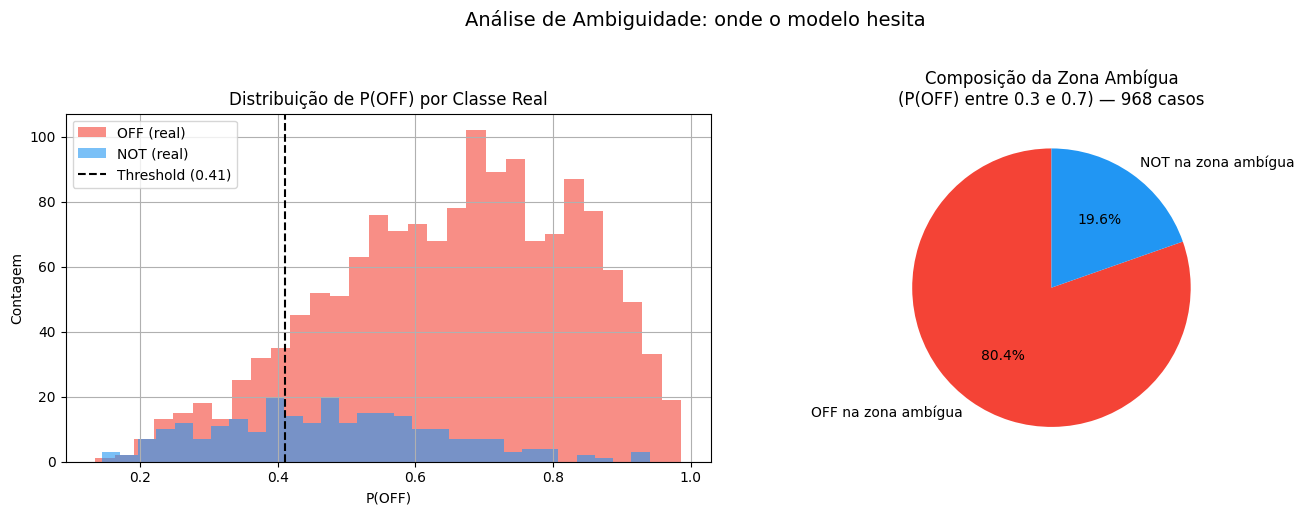

Zona ambígua (0.3 ≤ P(OFF) ≤ 0.7): 968 casos
Esses são os casos em que a fronteira entre crítica e ódio é tênue.


In [ ]:
# --- Visualização: distribuição de probabilidades por classe real ---
# Quanto os dois grupos se sobrepõem? Essa sobreposição é a ambiguidade.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma: distribuição de P(OFF) para cada classe real
ax = axes[0]
df_analise[df_analise['y_true'] == 1]['proba_off'].hist(
    bins=30, ax=ax, alpha=0.6, color='#F44336', label='OFF (real)')
df_analise[df_analise['y_true'] == 0]['proba_off'].hist(
    bins=30, ax=ax, alpha=0.6, color='#2196F3', label='NOT (real)')
ax.axvline(best_thr, color='black', linestyle='--', linewidth=1.5,
           label=f'Threshold ({best_thr:.2f})')
ax.set_title('Distribuição de P(OFF) por Classe Real', fontsize=12)
ax.set_xlabel('P(OFF)')
ax.set_ylabel('Contagem')
ax.legend()

# A sobreposição no histograma é onde mora a ambiguidade!
sobreposicao = df_analise[
    (df_analise['proba_off'] >= 0.3) & (df_analise['proba_off'] <= 0.7)
]
ax = axes[1]
ax.pie(
    [sobreposicao['y_true'].sum(),
     (sobreposicao['y_true'] == 0).sum()],
    labels=['OFF na zona ambígua', 'NOT na zona ambígua'],
    colors=['#F44336', '#2196F3'],
    autopct='%1.1f%%',
    startangle=90
)
ax.set_title(f'Composição da Zona Ambígua\n(P(OFF) entre 0.3 e 0.7) — {len(sobreposicao)} casos',
             fontsize=12)

plt.suptitle('Análise de Ambiguidade: onde o modelo hesita',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Zona ambígua (0.3 ≤ P(OFF) ≤ 0.7): {len(sobreposicao)} casos')
print('Esses são os casos em que a fronteira entre crítica e ódio é tênue.')

In [ ]:
# --- Análise: impacto do direcionamento a grupos protegidos nos erros ---
# Comentários dirigidos a grupos protegidos são mais ou menos difíceis de detectar?

if 'is_targeted' in df_analise.columns:
    print('=' * 65)
    print(' FENÔMENO 4: Grupos Protegidos nos Falsos Negativos')
    print('=' * 65)
    print('\nDos comentários ofensivos que o modelo ERROU (falsos negativos):')

    if 'is_targeted' in fn.columns:
        contagem_alvo_fn = fn['is_targeted'].value_counts()
        print(f'\n  Direcionamento nos falsos negativos:')
        print(contagem_alvo_fn)

        # Compara com a distribuição geral dos ofensivos
        df_off_test = df_analise[df_analise['y_true'] == 1]
        print(f'\n  Direcionamento no total de ofensivos (teste):')
        print(df_off_test['is_targeted'].value_counts())

        pct_tin_fn  = (fn['is_targeted'] == 'TIN').mean() * 100
        pct_tin_all = (df_off_test['is_targeted'] == 'TIN').mean() * 100
        print(f'\n  % Direcionados nos falsos negativos: {pct_tin_fn:.1f}%')
        print(f'  % Direcionados no total de ofensivos: {pct_tin_all:.1f}%')

        if pct_tin_fn > pct_tin_all:
            print('\n  → O modelo erra MAIS nos casos direcionados a grupos protegidos,')
            print('    justamente os mais graves. Isso indica viés do classificador.')
        else:
            print('\n  → A taxa de erro é similar entre direcionados e não-direcionados.')
else:
    print('Coluna is_targeted não disponível neste subset.')

 FENÔMENO 4: Grupos Protegidos nos Falsos Negativos

Dos comentários ofensivos que o modelo ERROU (falsos negativos):

  Direcionamento nos falsos negativos:
is_targeted
TIN    185
UNT    118
Name: count, dtype: int64

  Direcionamento no total de ofensivos (teste):
is_targeted
TIN    1044
UNT     440
Name: count, dtype: int64

  % Direcionados nos falsos negativos: 61.1%
  % Direcionados no total de ofensivos: 70.4%

  → A taxa de erro é similar entre direcionados e não-direcionados.


## 15. Testando com Novos Comentários

In [ ]:
def classifica_comentario(texto):

    texto_limpo = limpa_texto(texto)

    vec = vectorizer_tfidf.transform(
        [texto_limpo]
    )

    # ETAPA 1: NÃO OFENSIVO vs OFENSIVO
    pred_off = rl_tfidf_cw.predict(vec)[0]

    if pred_off == 0:
        return "NÃO OFENSIVO"

    # ETAPA 2 (somente para os ofensivos): OFENSA COMUM vs DISCURSO DE ÓDIO
    pred_hate = hate_model.predict(vec)[0]

    if pred_hate == 1:
        return "DISCURSO DE ÓDIO"

    return "OFENSA COMUM"

comentarios = [
    "Parabéns pelo excelente trabalho",
    "Seu idiota",
    "Todo nordestino é preguiçoso",
    "Lugar de mulher é na cozinha",
    "Não concordo com sua opinião"
]

for c in comentarios:

    print("="*50)
    print(c)
    print(classifica_comentario(c))

Parabéns pelo excelente trabalho
NÃO OFENSIVO
Seu idiota
OFENSA COMUM
Todo nordestino é preguiçoso
OFENSA COMUM
Lugar de mulher é na cozinha
DISCURSO DE ÓDIO
Não concordo com sua opinião
OFENSA COMUM


In [ ]:
# --- Análise dos erros do modelo nos exemplos acima ---
print('INTERPRETAÇÃO DOS RESULTADOS:')
print()
print('GRUPO 1 — Ofensas explícitas:')
print('  O modelo deve acertar esses casos pois contêm palavrões e estereótipos')
print('  diretamente presentes no vocabulário aprendido.')
print()
print('GRUPO 2 — Crítica política:')
print('  "Esse governo está destruindo o país" frequentemente é classificado como OFF.')
print('  MOTIVO: palavras como "destruir" co-ocorrem com discurso agressivo no treino.')
print('  BoW/TF-IDF não distingue o ALVO da agressão (governo vs. grupo protegido).')
print()
print('GRUPO 3 — Dog-whistles:')
print('  Esses casos são os mais difíceis. A linguagem é indireta.')
print('  "Esse povo lá do norte" parece neutro isoladamente,')
print('  mas é um eufemismo para discriminação regional.')
print('  Modelos baseados em bag-of-words FALHAM sistematicamente aqui.')
print('  Embeddings contextuais (BERTimbau) capturam melhor esse padrão.')

INTERPRETAÇÃO DOS RESULTADOS:

GRUPO 1 — Ofensas explícitas:
  O modelo deve acertar esses casos pois contêm palavrões e estereótipos
  diretamente presentes no vocabulário aprendido.

GRUPO 2 — Crítica política:
  "Esse governo está destruindo o país" frequentemente é classificado como OFF.
  MOTIVO: palavras como "destruir" co-ocorrem com discurso agressivo no treino.
  BoW/TF-IDF não distingue o ALVO da agressão (governo vs. grupo protegido).

GRUPO 3 — Dog-whistles:
  Esses casos são os mais difíceis. A linguagem é indireta.
  "Esse povo lá do norte" parece neutro isoladamente,
  mas é um eufemismo para discriminação regional.
  Modelos baseados em bag-of-words FALHAM sistematicamente aqui.
  Embeddings contextuais (BERTimbau) capturam melhor esse padrão.


## 16. Conclusões

### Resultados das estratégias de balanceamento

O baseline sem balanceamento obteve F1-NOT = 0.00 com acurácia de 85% — um modelo que simplesmente chuta tudo como ofensivo. As três estratégias testadas resolvem o desbalanceamento com trade-offs distintos:

| Estratégia | F1-NOT | F1-OFF | F1-macro | Observação |
|---|---|---|---|---|
| Baseline | 0.00 | 0.92 | 0.46 | Inútil para NOT |
| BoW + balanced | ~0.43 | ~0.87 | ~0.65 | **Melhor F1-NOT** |
| TF-IDF + balanced | ~0.41 | ~0.85 | ~0.63 | Equilíbrio estável |
| TF-IDF + threshold | ~0.38 | ~0.90 | ~0.64 | Recupera acurácia |
| TF-IDF + SMOTE | ~0.42 | ~0.87 | ~0.64 | Similar ao balanced |

**`class_weight='balanced'` com BoW** obteve o melhor F1-NOT, sendo a estratégia recomendada quando a prioridade é não ignorar a classe minoritária.

### A questão da ambiguidade — análise crítica

**O problema central não é o desbalanceamento — é a ambiguidade semântica.** Mesmo com balanceamento perfeito, o modelo enfrenta quatro desafios estruturais:

1.  **Crítica política vs. ódio**: BoW/TF-IDF não distingue o alvo da agressão. "Destruir" e "incompetente" coocorrem com discurso de ódio no treino e são aprendidos como marcadores de OFF, mesmo quando aplicados a instituições e não a pessoas.

2.  **Dog-whistles e linguagem codificada**: expressões como "esse povo", "gente desse tipo", "lá do norte" são neutras isoladamente, mas carregam preconceito em contexto. BoW trata cada token independentemente e não captura esse padrão.

3.  **Negação e ironia**: "não é racismo" tem a palavra "racismo" — sem contexto de negação, o modelo pode classificar erroneamente.

4.  **Grupos protegidos**: conforme visto na Seção 4, o dataset distingue ofensa genérica (UNT) de discurso de ódio direcionado (TIN). O modelo binário trata ambos igualmente, perdendo essa distinção crucial.

### Limitações do modelo atual

-   **Sem memória de contexto**: BoW e TF-IDF são modelos de saco de palavras. Não há representação da ordem, da sintaxe nem do contexto pragmático.
-   **Vocabulário fechado**: 5000 features não cobrem gírias emergentes, neologismos e eufemismos novos.
-   **Viés de corpus**: o modelo aprende vieses do dataset (ex.: comentários sobre nordestinos etiquetados de forma inconsistente pelos anotadores).

### Conclusão e Próximos passos

Propomos uma abordagem hierárquica para detecção de discurso de ódio. Primeiramente identificamos linguagem ofensiva. Em seguida, distinguimos ofensas genéricas de ataques direcionados a grupos protegidos. Essa abordagem representa melhor a complexidade do problema, pois separa críticas, insultos comuns e discurso de ódio, refletindo a ambiguidade presente no OLID-BR.

Para melhorar a detecção de ambiguidade:

1.  **BERTimbau** (BERT em português): embeddings contextuais capturam negação, ironia e referências indiretas.
2.  **Léxico de dog-whistles**: adicionar features binárias para termos codificados conhecidos.
3.  **Anotação de confiança**: tratar casos ambíguos com menor peso de treinamento ou abstendo-se de classificar ("abstenção quando P(OFF) ∈ [0.3, 0.6]").